# Data Demo: EEG Motor Imagery Dataset

This notebook demonstrates the dataset class used in this project.

It loads the PhysioNet EEG Motor Movement/Imagery EDF files, extracts event-based EEG windows from T1/T2 annotations, and compares full-channel and reduced-channel EEG inputs.

The main task is binary classification:

- T1 = imagined left fist
- T2 = imagined right fist

The dataset class is imported from `src/eeg_project/dataset.py`.

In [7]:
from pathlib import Path
import sys

# Find project root by looking for pyproject.toml
root = Path.cwd().resolve()

while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent

sys.path.insert(0, str(root / "src"))

print("Project root:", root)
print("Source path:", root / "src")

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from eeg_project.dataset import (
    EEGMotorImageryDataset,
    discover_subjects,
    make_subject_splits,
    INDEX_TO_LABEL,
)

Project root: /Users/sunny/Desktop/eeg-project
Source path: /Users/sunny/Desktop/eeg-project/src


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from eeg_project.dataset import (
    EEGMotorImageryDataset,
    discover_subjects,
    make_subject_splits,
    INDEX_TO_LABEL,
)

In [9]:
root = Path.cwd()

# If this notebook is opened from the notebooks folder, move back to project root.
if root.name == "notebooks":
    root = root.parent

data_dir = root / "data"

print("Project root:", root)
print("Data directory:", data_dir)
print("Data directory exists:", data_dir.exists())

Project root: /Users/sunny/Desktop/eeg-project
Data directory: /Users/sunny/Desktop/eeg-project/data
Data directory exists: True


In [10]:
subjects = discover_subjects(data_dir)

print("Number of subjects found:", len(subjects))
print("First 10 subjects:", subjects[:10])

Number of subjects found: 109
First 10 subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [11]:
train_subjects, val_subjects, test_subjects = make_subject_splits(subjects, seed=42)

print("Train subjects:", len(train_subjects), train_subjects[:10])
print("Validation subjects:", len(val_subjects), val_subjects[:10])
print("Test subjects:", len(test_subjects), test_subjects[:10])

Train subjects: 71 [1, 2, 3, 4, 5, 6, 8, 11, 16, 18]
Validation subjects: 19 [7, 10, 17, 31, 32, 35, 45, 49, 50, 55]
Test subjects: 19 [9, 12, 13, 14, 15, 20, 23, 36, 37, 42]


In [12]:
demo_subjects = subjects[:3]

full_dataset = EEGMotorImageryDataset(
    data_dir=data_dir,
    subjects=demo_subjects,
    channel_set="full",
    tmin=0.5,
    tmax=3.5,
    normalize=True,
)

motor_dataset = EEGMotorImageryDataset(
    data_dir=data_dir,
    subjects=demo_subjects,
    channel_set="motor21",
    tmin=0.5,
    tmax=3.5,
    normalize=True,
)

central_dataset = EEGMotorImageryDataset(
    data_dir=data_dir,
    subjects=demo_subjects,
    channel_set="central3",
    tmin=0.5,
    tmax=3.5,
    normalize=True,
)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).

In [13]:
print("Full-channel dataset summary:")
print(full_dataset.summary())

print("\nMotor-area reduced dataset summary:")
print(motor_dataset.summary())

print("\nCentral 3-channel dataset summary:")
print(central_dataset.summary())

Full-channel dataset summary:
{'data_dir': '/Users/sunny/Desktop/eeg-project/data', 'num_files': 9, 'num_samples': 135, 'subjects': [1, 2, 3], 'runs': [4, 8, 12], 'channel_set': 'full', 'num_channels': 64, 'channel_names': ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz'], 'sfreq': 160.0, 'num_timepoints': 480, 'label_counts': {'left_fist_imagery': 69, 'right_fist_imagery': 66}}

Motor-area reduced dataset summary:
{'data_dir': '/Users/sunny/Desktop/eeg-project/data', 'num_files': 9, 'num_samples': 135, 'subjects': [1, 2, 3], 'runs': [4, 8, 12], 'channel_set': 'motor21', 'num_channels': 21, 'channel_names': ['FC5', 'FC3', 'FC

In [14]:
x_full, y_full = full_dataset[0]
x_motor, y_motor = motor_dataset[0]
x_central, y_central = central_dataset[0]

print("Full x shape:", x_full.shape)
print("Full y:", y_full.item(), INDEX_TO_LABEL[y_full.item()])

print("\nMotor21 x shape:", x_motor.shape)
print("Motor21 y:", y_motor.item(), INDEX_TO_LABEL[y_motor.item()])

print("\nCentral3 x shape:", x_central.shape)
print("Central3 y:", y_central.item(), INDEX_TO_LABEL[y_central.item()])

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Full x shape: torch.Size([64, 480])
Full y: 1 right_fist_imagery

Motor21 x shape: torch.Size([21, 480])
Motor21 y: 1 right_fist_imagery

Central3 x shape: torch.Size([3, 480])
Central3 y: 1 right_fist_imagery


In [15]:
metadata = motor_dataset.get_metadata(0)
metadata

{'file_path': '/Users/sunny/Desktop/eeg-project/data/S001/S001R04.edf',
 'subject': 1,
 'run': 4,
 'annotation': np.str_('T2'),
 'label': 1,
 'label_name': 'right_fist_imagery',
 'start': 752,
 'stop': 1232}

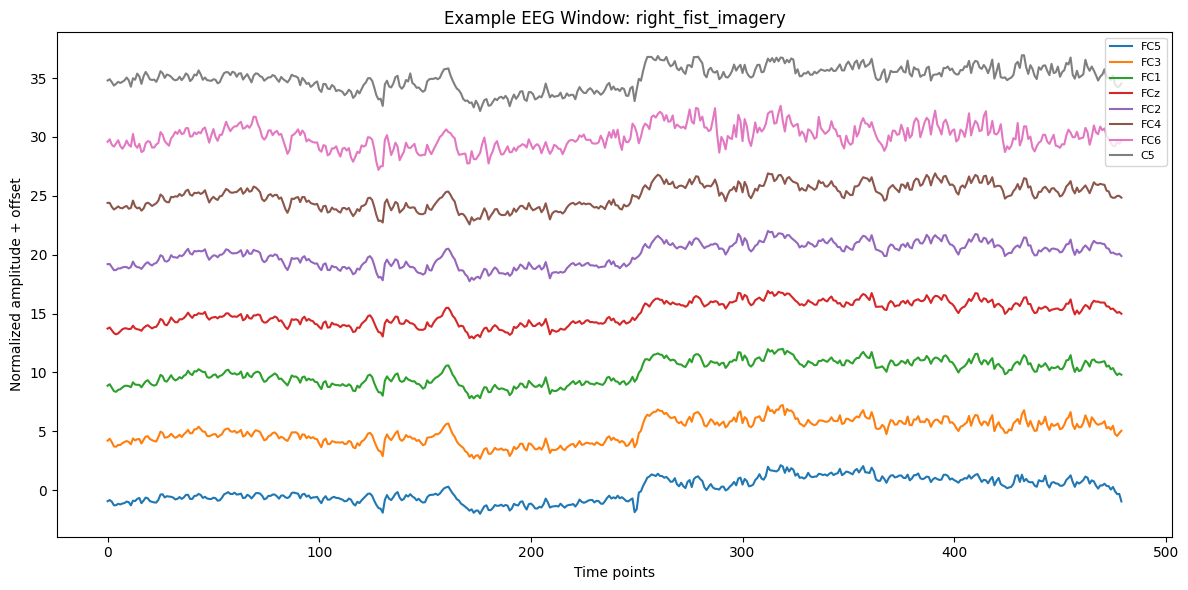

In [16]:
x, y = motor_dataset[0]

plt.figure(figsize=(12, 6))

for i in range(min(8, x.shape[0])):
    plt.plot(x[i].numpy() + i * 5, label=motor_dataset.channel_names[i])

plt.title(f"Example EEG Window: {INDEX_TO_LABEL[y.item()]}")
plt.xlabel("Time points")
plt.ylabel("Normalized amplitude + offset")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
loader = DataLoader(motor_dataset, batch_size=8, shuffle=True)

batch_x, batch_y = next(iter(loader))

print("Batch x shape:", batch_x.shape)
print("Batch y shape:", batch_y.shape)
print("Batch labels:", batch_y)
print("Label names:", [INDEX_TO_LABEL[int(y)] for y in batch_y])

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Batch x shape: torch.Size([8, 21, 480])
Batch y shape: torch.Size([8])
Batch labels: tensor([1, 0, 0, 0, 0, 0, 1, 1])
Label names: ['right_fist_imagery', 'left_fist_imagery', 'left_fist_imagery', 'left_fist_imagery', 'left_fist_imagery', 'left_fist_imagery', 'right_fist_imagery', 'right_fist_imagery']
